# Metrics dashboard

Visualises the JSON snapshots in `metrics/`:
- `investment_roi.json` — ROI economics across every listing + risk-premium sweep.
- `recommender_precision.json` — offline Precision@K of the recommender.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

METRICS_DIR = Path('..') / 'metrics'
roi = json.loads((METRICS_DIR / 'investment_roi.json').read_text(encoding='utf-8'))
precision = json.loads((METRICS_DIR / 'recommender_precision.json').read_text(encoding='utf-8'))

## 1. Investment verdict distribution (base scenario)

Base params: KZ inflation 12.3 %, risk premium 3 pp → 15.3 % discount rate.

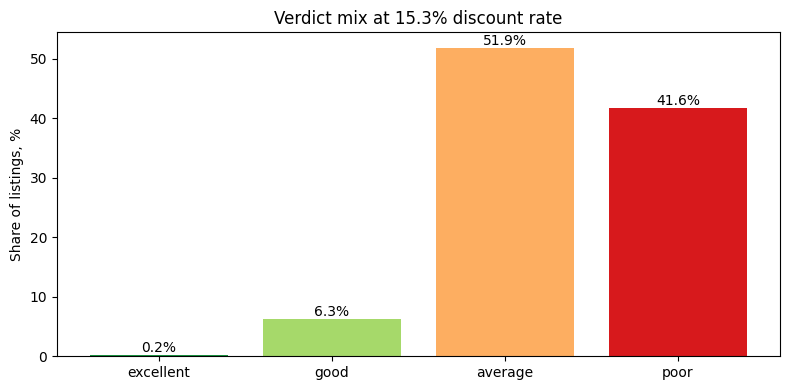

In [2]:
shares = roi['base_scenario']['verdict_shares']
order = ['excellent', 'good', 'average', 'poor']
values = [shares[k] * 100 for k in order]
colors = ['#1a9641', '#a6d96a', '#fdae61', '#d7191c']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(order, values, color=colors)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}%', ha='center', va='bottom')
ax.set_ylabel('Share of listings, %')
ax.set_title('Verdict mix at 15.3% discount rate')
plt.tight_layout()
plt.show()

What this shows: ~52 % of the market is 'average', ~42 % 'poor', only ~6 % 'good' and <0.2 % 'excellent'. This is the answer to the recurring 'why is everything poor?' question — the bar is high because KZ inflation alone eats 12.3 % a year, and we additionally demand a 3 pp real-estate risk premium.

## 2. How the verdict mix shifts with risk premium

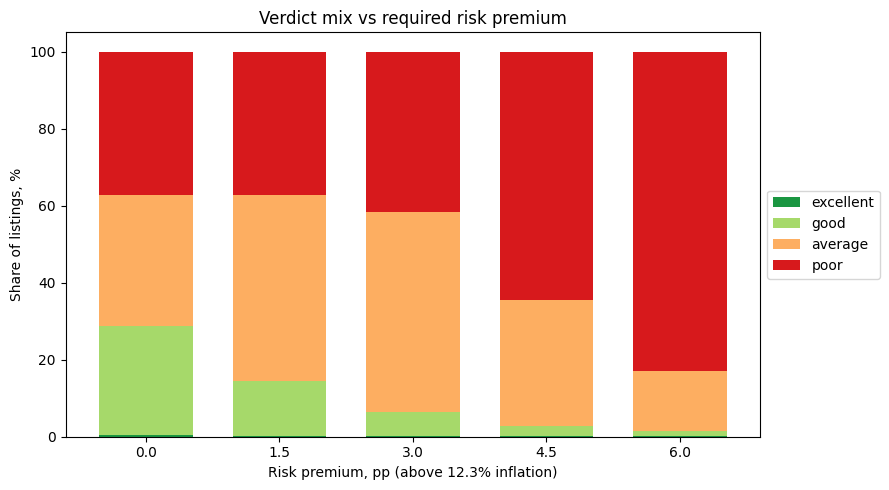

In [3]:
sweep = pd.DataFrame([
    {'risk_premium_pp': row['risk_premium_pct'], **row['verdict_shares']}
    for row in roi['risk_premium_sensitivity']
]).set_index('risk_premium_pp')[order]

fig, ax = plt.subplots(figsize=(9, 5))
(sweep * 100).plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.7)
ax.set_xlabel('Risk premium, pp (above 12.3% inflation)')
ax.set_ylabel('Share of listings, %')
ax.set_title('Verdict mix vs required risk premium')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

What this shows: at 0 pp risk premium (just covering inflation) about 28 % of listings are 'good or better'. By 6 pp almost nothing qualifies. The verdict is mostly driven by the assumed discount rate, not by the listings themselves — the production default of 3 pp is the most conservative choice that still leaves 'good' as an attainable label.

## 3. Distribution of inflation-adjusted payback (years)

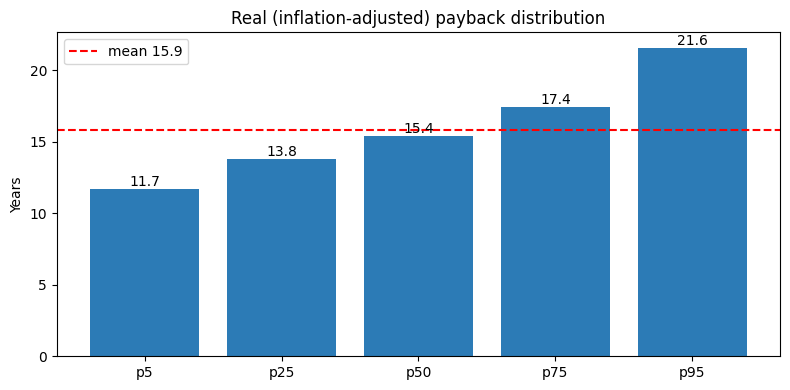

In [4]:
payback = roi['base_scenario']['metrics']['payback_years_inflation_adjusted']
percentiles = ['p5', 'p25', 'p50', 'p75', 'p95']
values = [payback[p] for p in percentiles]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(percentiles, values, color='#2c7bb6')
for i, val in enumerate(values):
    ax.text(i, val, f'{val:.1f}', ha='center', va='bottom')
ax.axhline(payback['mean'], color='red', linestyle='--', label=f"mean {payback['mean']:.1f}")
ax.set_ylabel('Years')
ax.set_title('Real (inflation-adjusted) payback distribution')
ax.legend()
plt.tight_layout()
plt.show()

What this shows: median real payback is ~15.4 years; even the best 5 % of listings need ~11.7 years. Holding period is the binding constraint for most Almaty apartments treated as rental investments.

## 4. Recommender Precision@K — per query

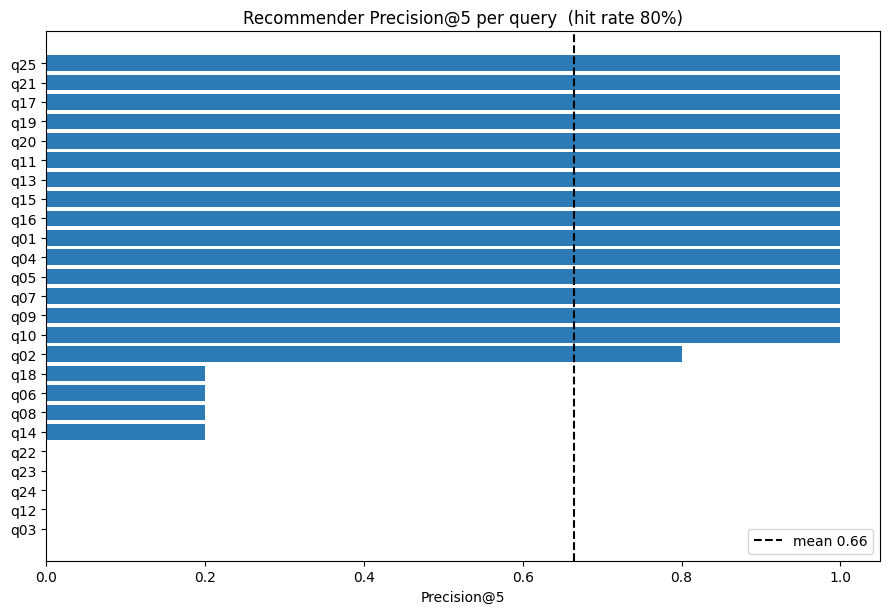

In [5]:
k5 = precision['k_5']
per_query = pd.DataFrame(k5['per_query']).sort_values('precision', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(per_query) * 0.25)))
ax.barh(per_query['id'], per_query['precision'],
        color=['#d7191c' if p == 0 else '#2c7bb6' for p in per_query['precision']])
ax.axvline(k5['mean_precision'], color='black', linestyle='--',
           label=f"mean {k5['mean_precision']:.2f}")
ax.set_xlabel('Precision@5')
ax.set_xlim(0, 1.05)
ax.set_title(f"Recommender Precision@5 per query  (hit rate {k5['hit_rate']:.0%})")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

What this shows: a majority of queries hit Precision@5 = 1.0, but a handful collapse to 0. The failing queries are usually the ones with very tight relevance rules (small candidate pool in `candidates_passing_rule`) or with `__error__` in `unmapped_preferences` from Gemini quota issues. Mean Precision@5 is 0.664 with a hit rate of 80 %.

## 5. Precision@5 vs candidate pool size

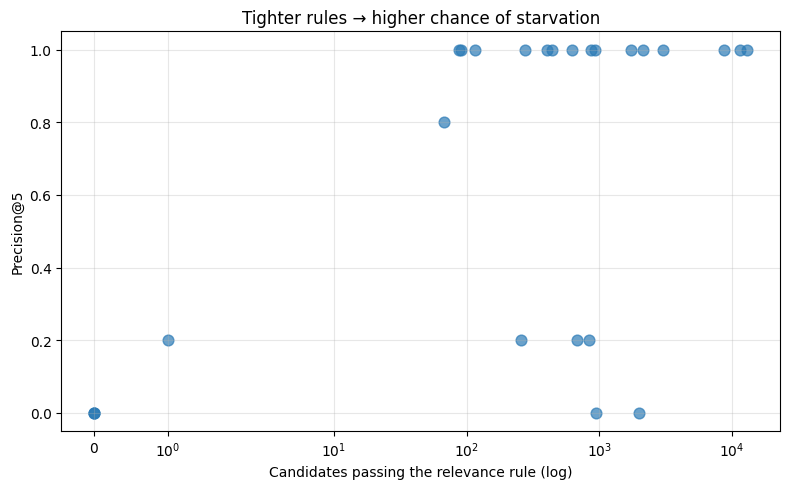

In [6]:
per_query_df = pd.DataFrame(k5['per_query'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(per_query_df['candidates_passing_rule'], per_query_df['precision'],
           s=60, alpha=0.7, color='#2c7bb6')
ax.set_xscale('symlog')
ax.set_xlabel('Candidates passing the relevance rule (log)')
ax.set_ylabel('Precision@5')
ax.set_title('Tighter rules → higher chance of starvation')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

What this shows: when the relevance rule is very restrictive (e.g. < 100 matching listings in the whole index), Precision@5 is volatile — some hit, some miss. Once the candidate pool is in the thousands, precision is consistently high. This is a property of the dataset rather than the recommender itself.